In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [31]:
sns.set_theme(style="whitegrid")

In [32]:
df = pd.read_csv("../data/raw/customer_churn.csv")

In [33]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [34]:
df.tail()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1
64373,64374,52,Female,45,15,9,25,Standard,Monthly,696,22,1


In [35]:
df.shape

(64374, 12)

In [36]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 5.9 MB


In [38]:
df.dtypes

CustomerID           int64
Age                  int64
Gender                 str
Tenure               int64
Usage Frequency      int64
Support Calls        int64
Payment Delay        int64
Subscription Type      str
Contract Length        str
Total Spend          int64
Last Interaction     int64
Churn                int64
dtype: object

In [39]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [40]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage

CustomerID           0.0
Age                  0.0
Gender               0.0
Tenure               0.0
Usage Frequency      0.0
Support Calls        0.0
Payment Delay        0.0
Subscription Type    0.0
Contract Length      0.0
Total Spend          0.0
Last Interaction     0.0
Churn                0.0
dtype: float64

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique()[:20])


CustomerID
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]

Age
[22 41 47 35 53 30 54 36 65 46 56 31 42 59 29 45 62 48 55 64]

Gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Tenure
[25 28 27  9 58 41 37 36 20  8 42 13  2 46 21  1 54 40 39 50]

Usage Frequency
[14 28 10 12 24 15 11  5  4 27 23  7 17  3 30  2 19 20 18  8]

Support Calls
[ 4  7  2  5  9 10  0  6  1  3  8]

Payment Delay
[27 13 29 17  2 10 28 18  8 23 21 14 25  3  6 15  1  9 30  4]

Subscription Type
<StringArray>
['Basic', 'Standard', 'Premium']
Length: 3, dtype: str

Contract Length
<StringArray>
['Monthly', 'Annual', 'Quarterly']
Length: 3, dtype: str

Total Spend
[598 584 757 232 533 500 574 323 687 995 526 187 758 438 663 677 636 127
 396 202]

Last Interaction
[ 9 20 21 18 29 14 16  8 10  3  1 24 30 15 25 22 13 26 12  4]

Churn
[1 0]


In [43]:
print(df["Gender"].unique())
print(df["Subscription Type"].unique())
print(df["Contract Length"].unique())
print(df["Churn"].unique())

<StringArray>
['Female', 'Male']
Length: 2, dtype: str
<StringArray>
['Basic', 'Standard', 'Premium']
Length: 3, dtype: str
<StringArray>
['Monthly', 'Annual', 'Quarterly']
Length: 3, dtype: str
[1 0]


In [44]:
df["Gender"].value_counts()

Gender
Female    34353
Male      30021
Name: count, dtype: int64

In [45]:
df["Subscription Type"].value_counts()

Subscription Type
Standard    21502
Basic       21451
Premium     21421
Name: count, dtype: int64

In [46]:
df["Contract Length"].value_counts()

Contract Length
Monthly      22130
Annual       21410
Quarterly    20834
Name: count, dtype: int64

In [47]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [48]:
df.describe(include="object")

C:\Users\KARTIK PRAJAPATI\AppData\Local\Temp\ipykernel_36288\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Gender,Subscription Type,Contract Length
count,64374,64374,64374
unique,2,3,3
top,Female,Standard,Monthly
freq,34353,21502,22130


In [49]:
df["Churn"].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

In [50]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64

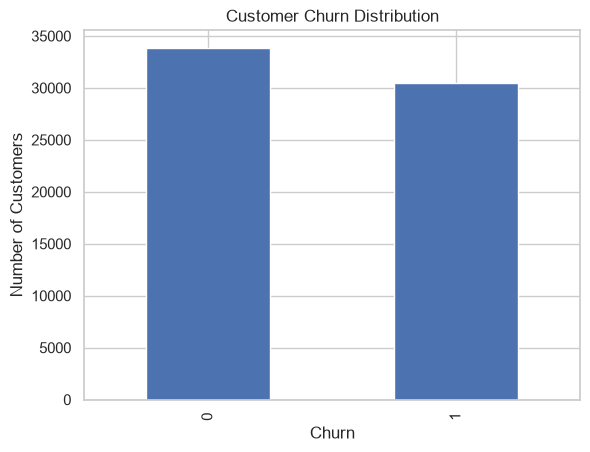

In [53]:
df["Churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [54]:
churn_percentage = (
    df["Churn"].value_counts(normalize=True) * 100
)

print(churn_percentage)

Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64


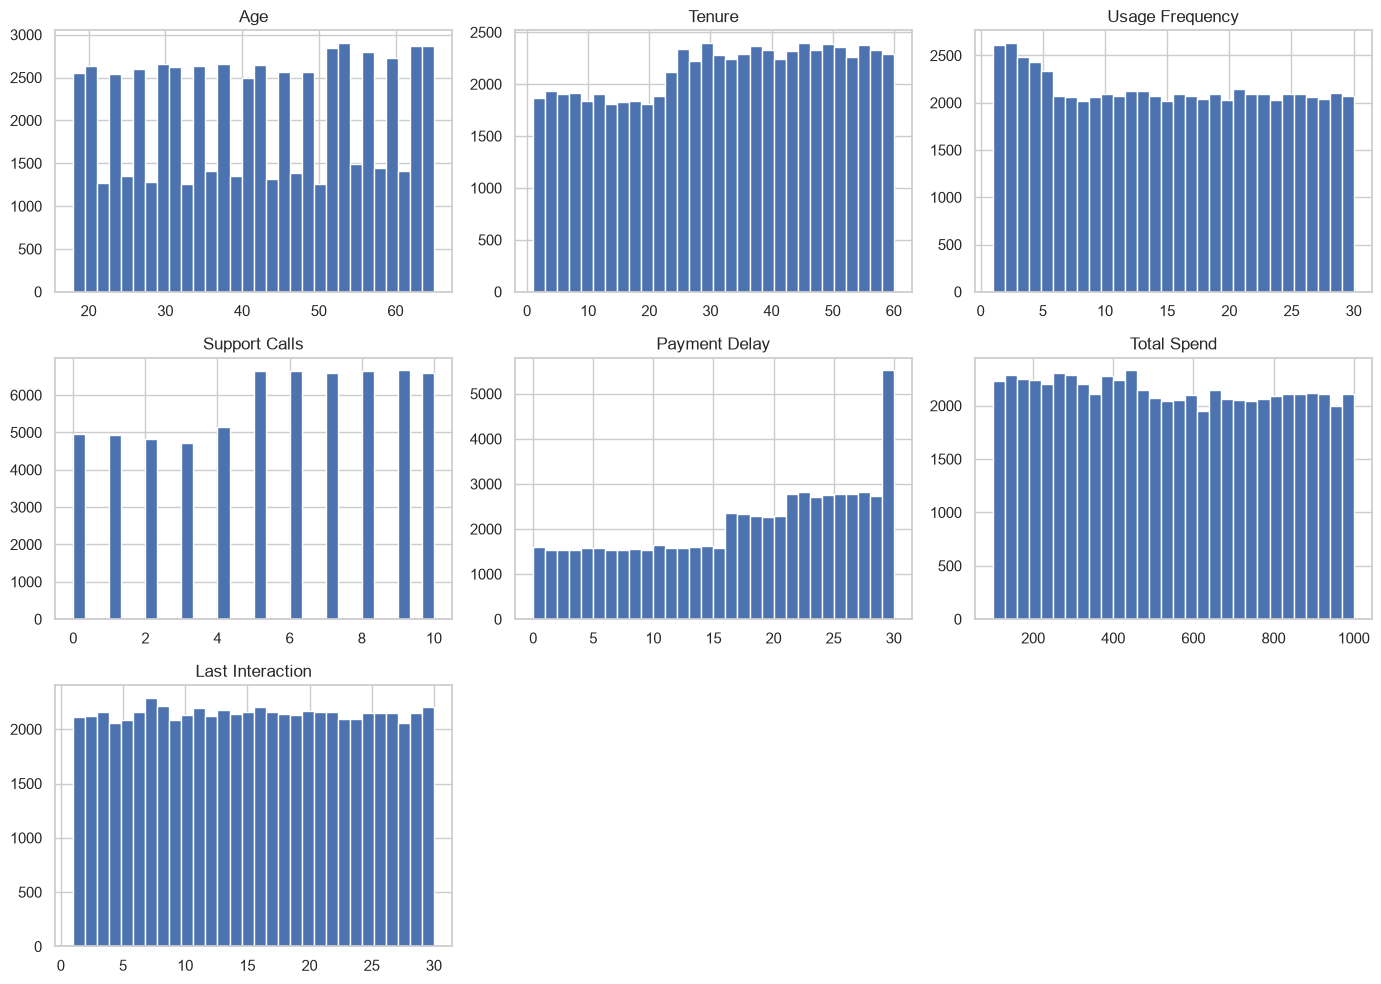

In [56]:
numerical_features = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction"
]


df[numerical_features].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

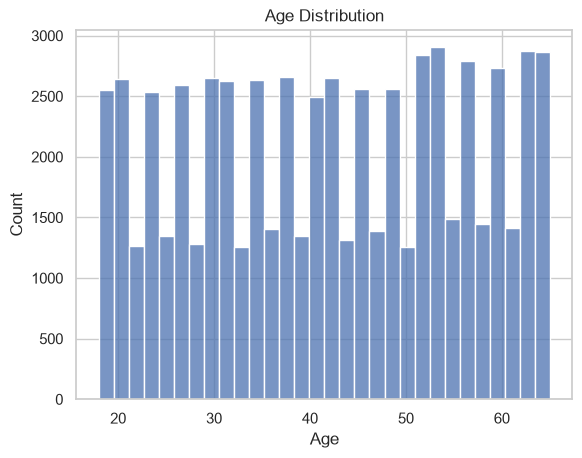

In [57]:
sns.histplot(
    data=df,
    x="Age",
    bins=30
)

plt.title("Age Distribution")
plt.show()

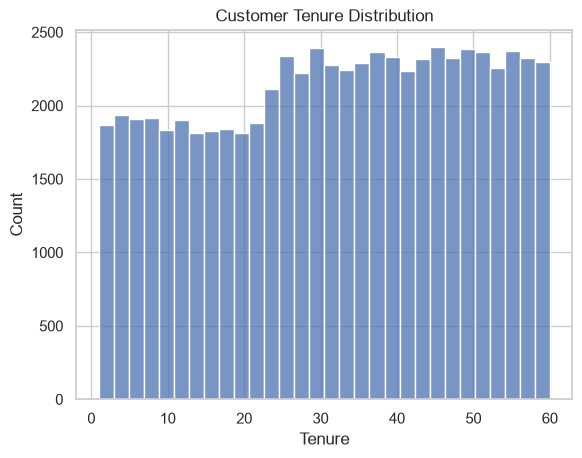

In [58]:
sns.histplot(
    data=df,
    x="Tenure",
    bins=30
)
plt.title("Customer Tenure Distribution")
plt.show()

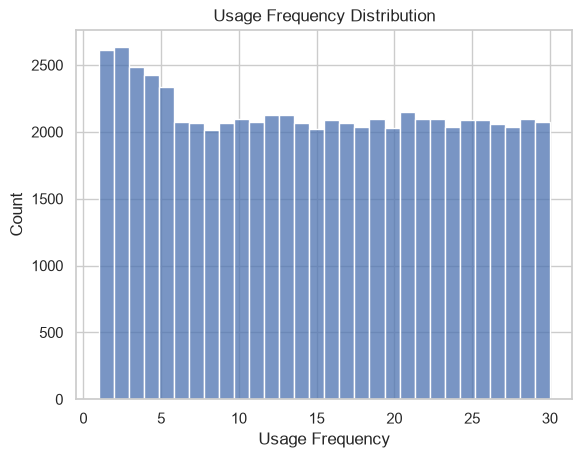

In [59]:
sns.histplot(
    data=df,
    x="Usage Frequency",
    bins=30
)

plt.title("Usage Frequency Distribution")
plt.show()

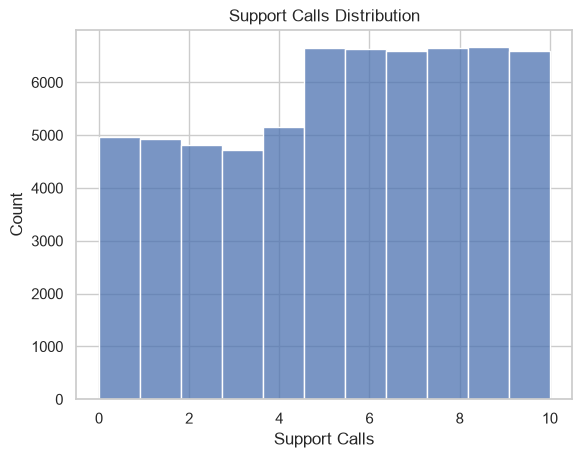

In [62]:
sns.histplot(
    data=df,
    x="Support Calls",
    bins=11
)

plt.title("Support Calls Distribution")
plt.show()

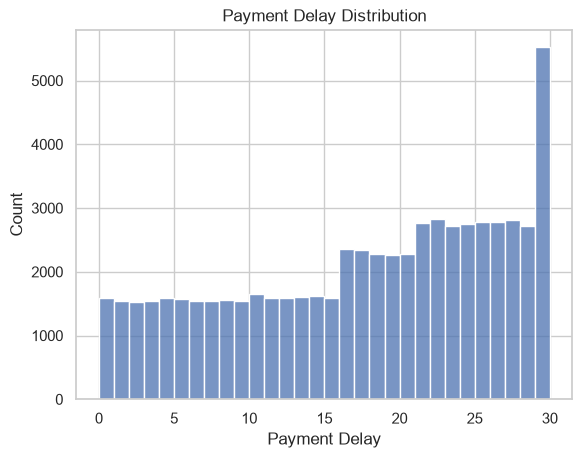

In [63]:
sns.histplot(
    data=df,
    x="Payment Delay",
    bins=30
)

plt.title("Payment Delay Distribution")
plt.show()

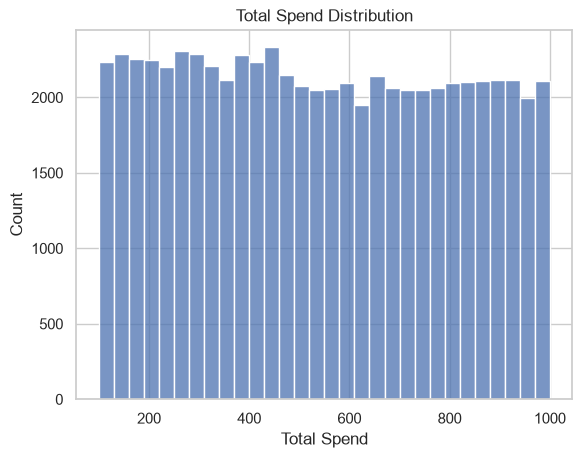

In [64]:
sns.histplot(
    data=df,
    x="Total Spend",
    bins=30
)

plt.title("Total Spend Distribution")
plt.show()

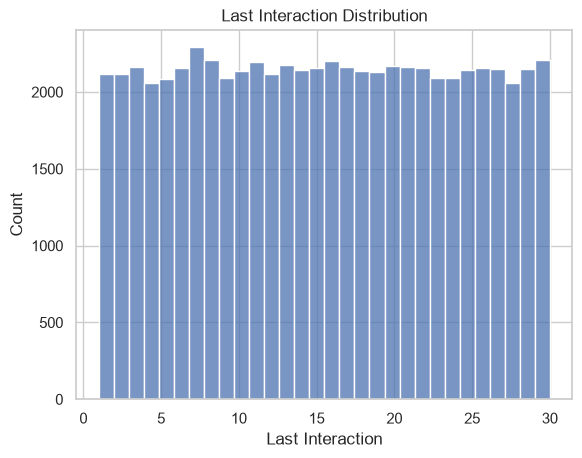

In [65]:
sns.histplot(
    data=df,
    x="Last Interaction",
    bins=30
)

plt.title("Last Interaction Distribution")
plt.show()

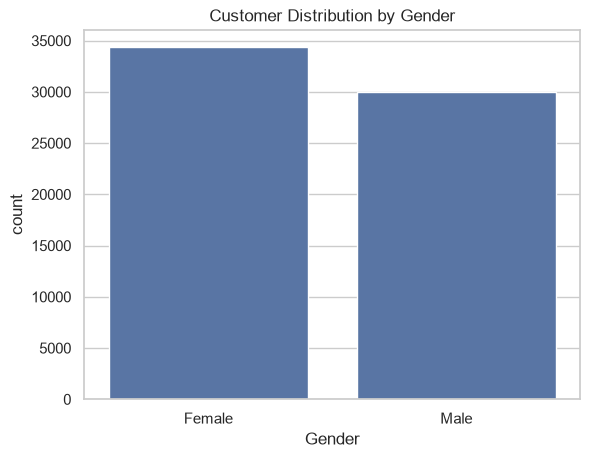

In [66]:
sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Distribution by Gender")
plt.show()

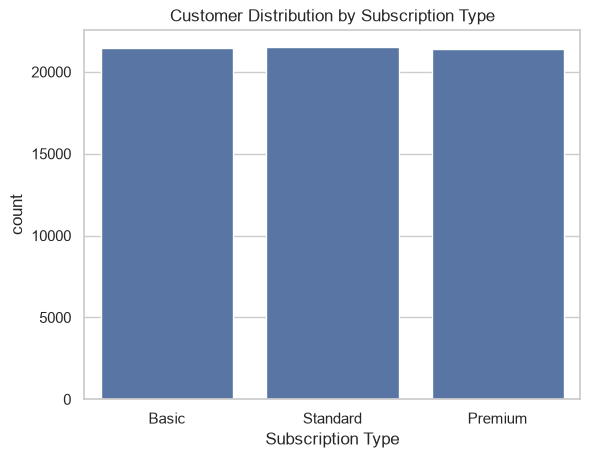

In [67]:
sns.countplot(
    data=df,
    x="Subscription Type"
)

plt.title("Customer Distribution by Subscription Type")
plt.show()

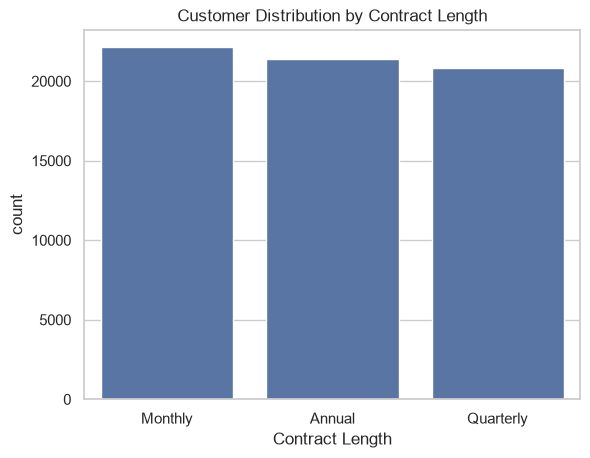

In [68]:
sns.countplot(
    data=df,
    x="Contract Length"
)

plt.title("Customer Distribution by Contract Length")
plt.show()

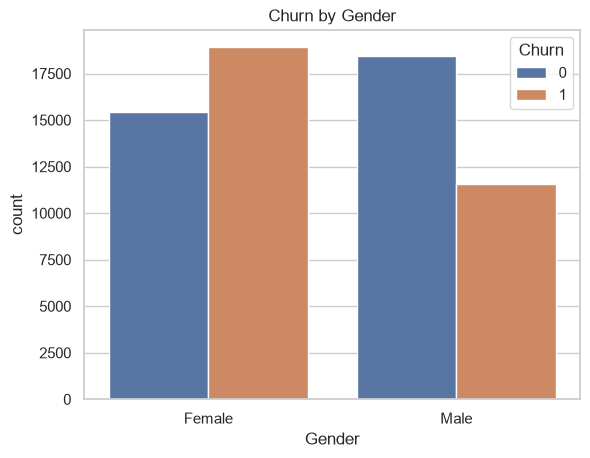

In [69]:
sns.countplot(
    data=df,
    x="Gender",
    hue="Churn"
)

plt.title("Churn by Gender")
plt.show()

In [70]:
gender_churn = pd.crosstab(
    df["Gender"],
    df["Churn"],
    normalize="index"
) * 100

gender_churn

Churn,0,1
Gender,,
Female,44.950950,55.049050
Male,61.420339,38.579661


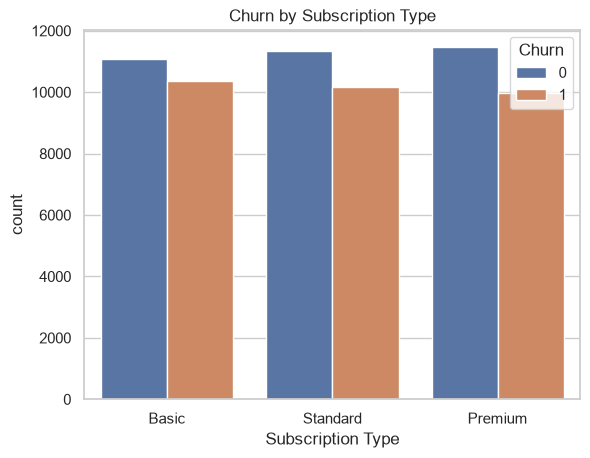

In [71]:
sns.countplot(
    data=df,
    x="Subscription Type",
    hue="Churn"
)

plt.title("Churn by Subscription Type")
plt.show()

In [72]:
subscription_churn = pd.crosstab(
    df["Subscription Type"],
    df["Churn"],
    normalize="index"
) * 100

subscription_churn

Churn,0,1
Subscription Type,,
Basic,51.722530,48.277470
Premium,53.503571,46.496429
Standard,52.669519,47.330481


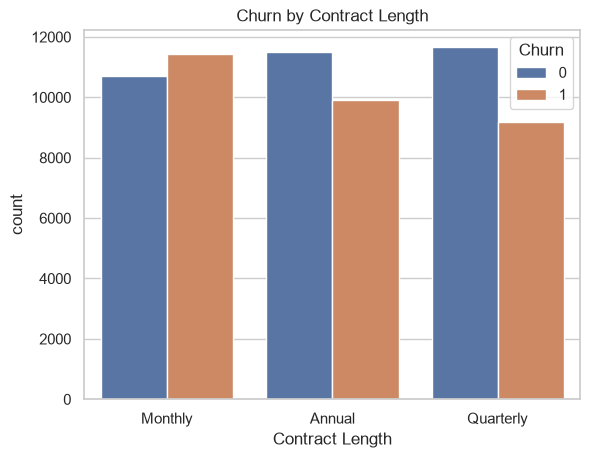

In [73]:
sns.countplot(
    data=df,
    x="Contract Length",
    hue="Churn"
)

plt.title("Churn by Contract Length")
plt.show()

In [74]:
contract_churn = pd.crosstab(
    df["Contract Length"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,0,1
Contract Length,,
Annual,53.783279,46.216721
Monthly,48.391324,51.608676
Quarterly,55.951810,44.048190


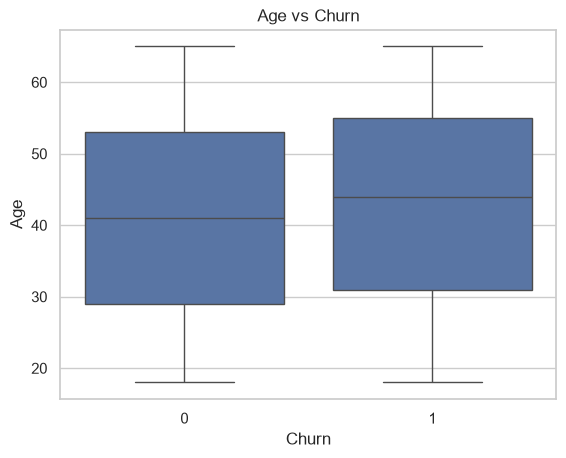

In [75]:
sns.boxplot(
    data=df,
    x="Churn",
    y="Age"
)

plt.title("Age vs Churn")
plt.show()

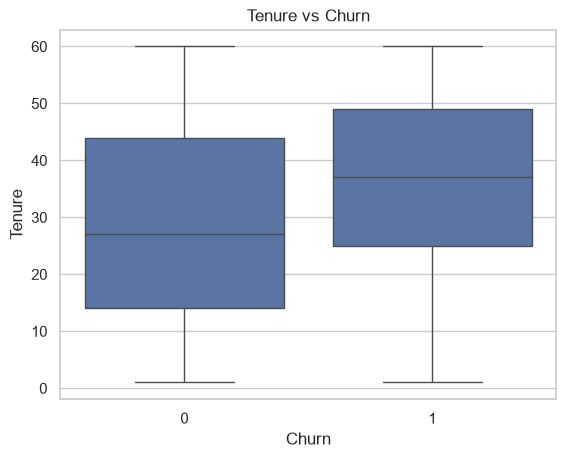

In [76]:
sns.boxplot(
    data=df,
    x="Churn",
    y="Tenure"
)

plt.title("Tenure vs Churn")
plt.show()

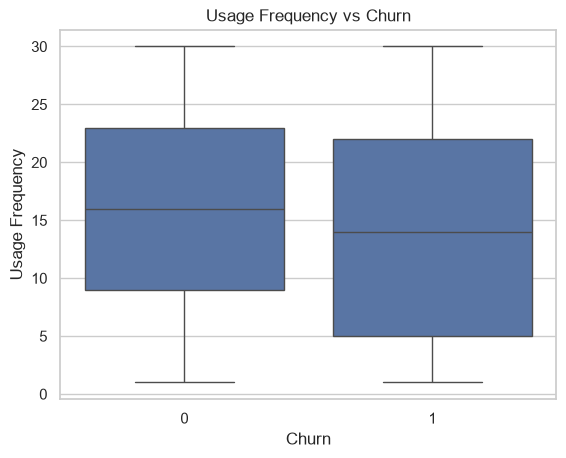

In [77]:
sns.boxplot(
    data=df,
    x="Churn",
    y="Usage Frequency"
)

plt.title("Usage Frequency vs Churn")
plt.show()

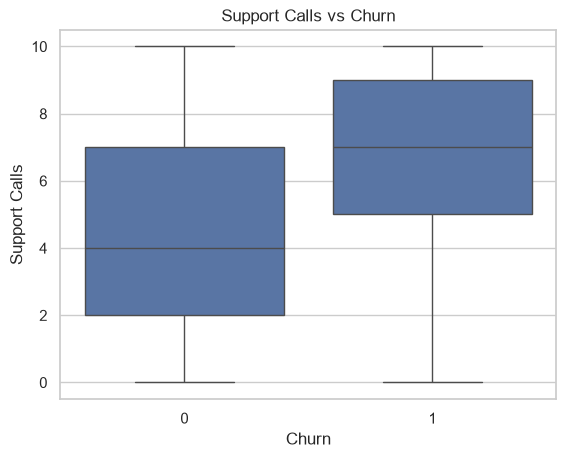

In [78]:
sns.boxplot(
    data=df,
    x="Churn",
    y="Support Calls"
)

plt.title("Support Calls vs Churn")
plt.show()

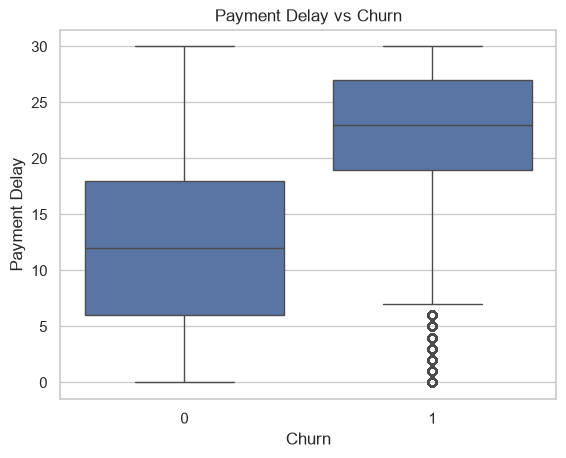

In [79]:
sns.boxplot(
    data=df,
    x="Churn",
    y="Payment Delay"
)

plt.title("Payment Delay vs Churn")
plt.show()

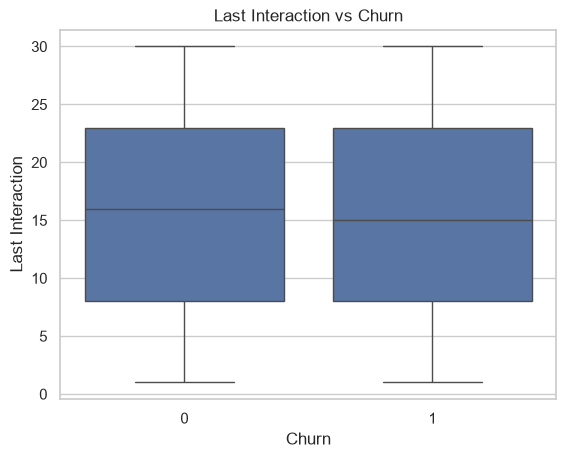

In [80]:
sns.boxplot(
    data=df,
    x="Churn",
    y="Last Interaction"
)

plt.title("Last Interaction vs Churn")
plt.show()

In [81]:
correlation = df[numerical_features + ["Churn"]].corr()

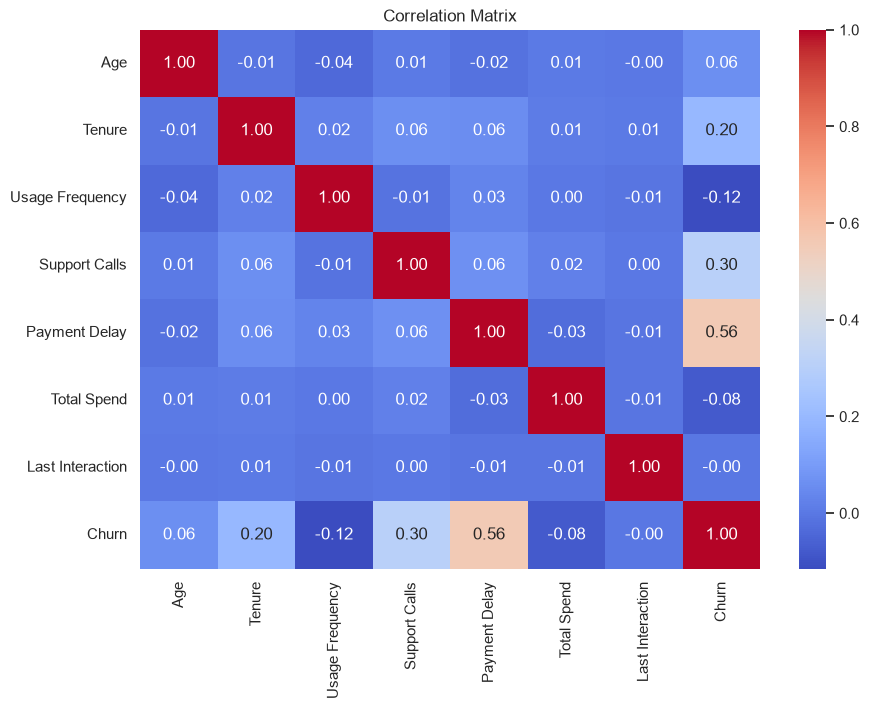

In [82]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

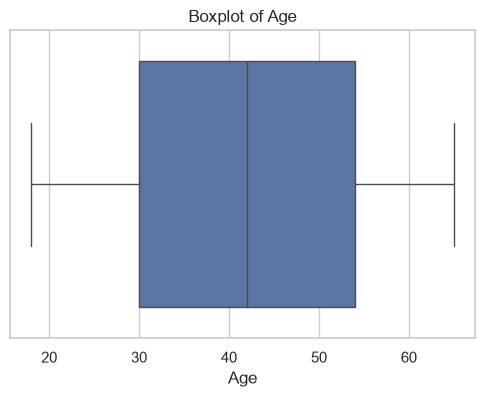

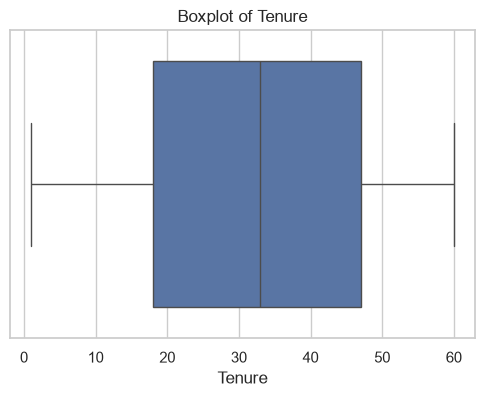

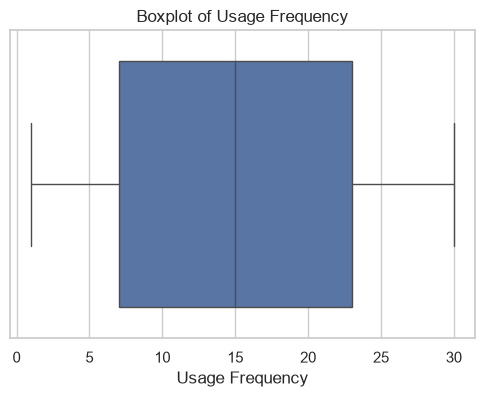

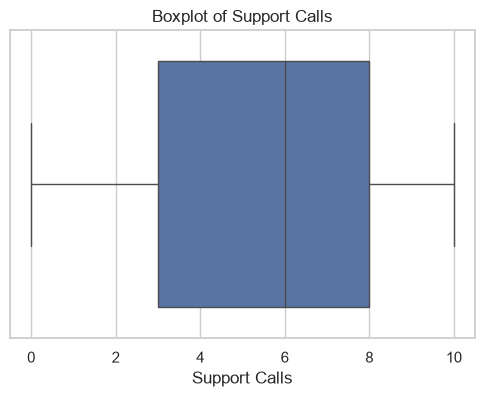

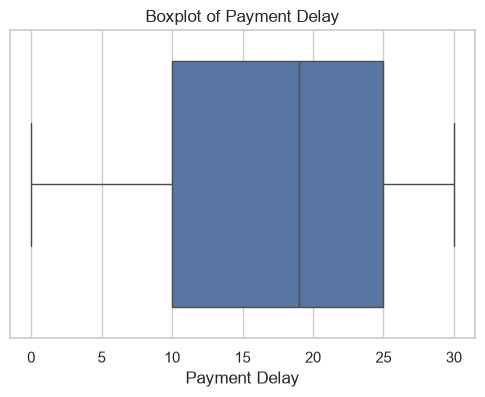

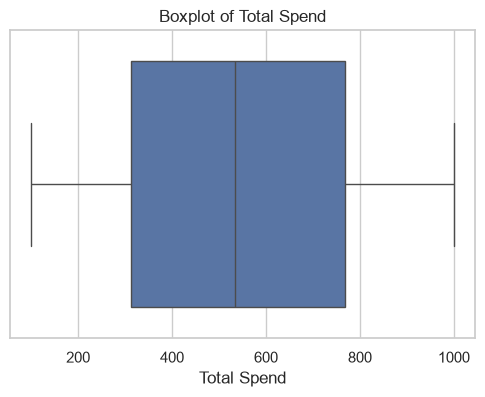

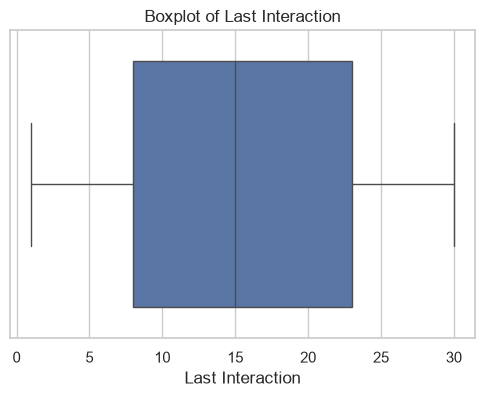

In [83]:
for column in numerical_features:
    plt.figure(figsize=(6, 4))
    
    sns.boxplot(
        x=df[column]
    )
    
    plt.title(f"Boxplot of {column}")
    plt.show()

# EDA Findings


## Dataset Overview

- Number of records:
- Number of features:
- Target variable:
- Missing values:
- Duplicate records:

## Target Distribution

- Non-churn customers:
- Churn customers:
- Churn percentage:

## Numerical Features

- Age:
- Tenure:
- Usage Frequency:
- Support Calls:
- Payment Delay:
- Total Spend:
- Last Interaction:

## Categorical Features

- Gender:
- Subscription Type:
- Contract Length:

## Important Churn Patterns

1.
2.
3.
4.
5.

## Outlier Observations

1.
2.
3.

## Initial Feature Engineering Ideas

1.
2.
3.